# Estimate GHF from basal temperature posterior

In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.model as model
import os
import scipy.io

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
split_data_path = "../data/train-validate-test/" # split data set
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
GHF_mean_filename    = 'trainingAll_GHF_sim_mean.mat'
GHF_std_filename     = 'trainingAll_GHF_sim_std.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
GHF_standardize_epsilon = preprocess_param['GHF_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("GHF_standardize_epsilon:", GHF_standardize_epsilon)

flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)
GHF_mean         = scipy.io.loadmat(folder + GHF_mean_filename)
GHF_std          = scipy.io.loadmat(folder + GHF_std_filename)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
GHF_standardized_train = np.load(split_data_path + XY_train_filename)['GHF_train']
GHF_standardized_valid = np.load(split_data_path + XY_valid_filename)['GHF_validation']
GHF_standardized_test  = np.load(split_data_path + XY_test_filename)['GHF_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()
GHF_mean = np.nan_to_num(GHF_mean['GHF_mean'], nan=0.0).flatten()
GHF_std  = np.nan_to_num(GHF_std['GHF_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of GHF_standardized_train:', GHF_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)


Eb_standardize_epsilon: 1287.4819202075
GHF_standardize_epsilon: 0.0181090261526068
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of GHF_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)


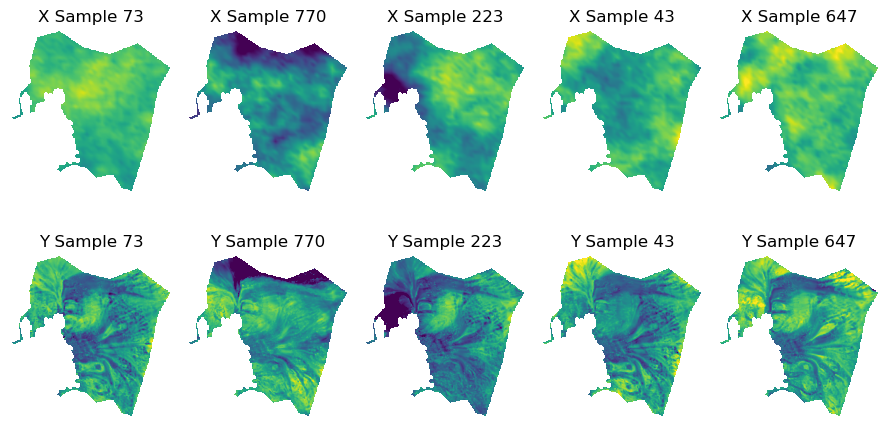

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
GHF_standardized_all = np.concatenate([GHF_standardized_train, 
                                       GHF_standardized_valid, 
                                       GHF_standardized_test], 
                                       axis=3)
md.load_sim_data(GHF_standardized_all, Eb_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 show_plot=True)

md.load_standardization_data(X_mean=GHF_mean, X_std=GHF_std,
                             Y_mean=Eb_mean, Y_std=Eb_std,
                             X_epsilon=GHF_standardize_epsilon, Y_epsilon=Eb_standardize_epsilon)

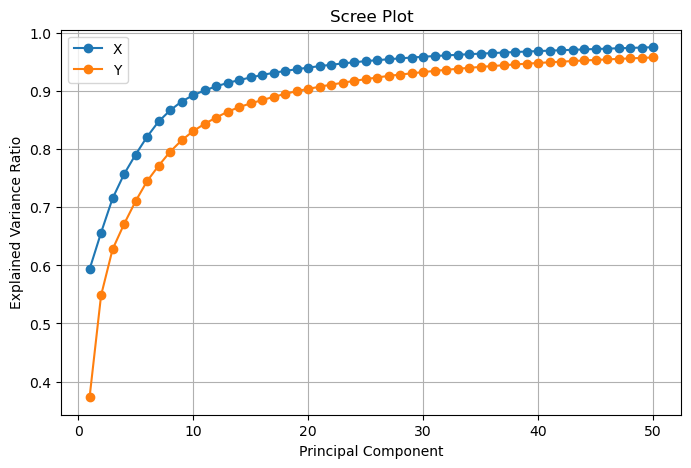

In [3]:
md.pca_scree(n_component_x=50, n_component_y=50)

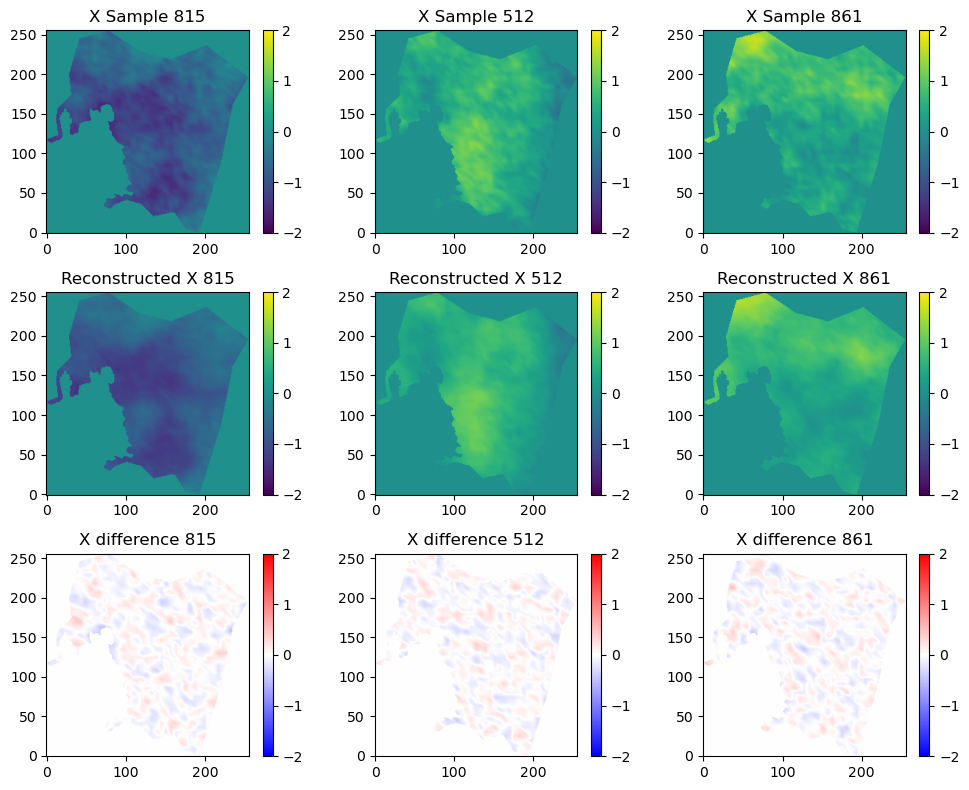

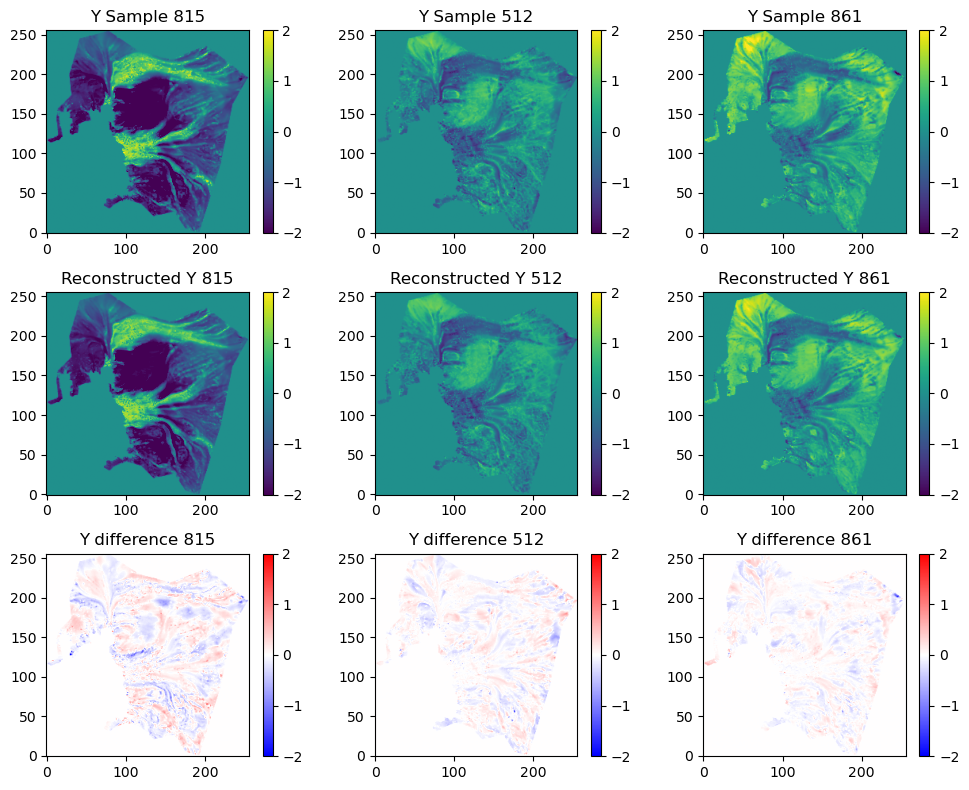

In [4]:
md.pca_recon_inspection(n_component_x=50, n_component_y=50)

In [3]:
# PCA + PLS
# md.find_reduction_model_pca(n_component_x=20, n_component_y=20)
md.find_reduction_model_pls(n_pca_x=50, n_pca_y=50, n_pls=40)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PLS
md.load_split_data_pls(X_train=GHF_standardized_train, Y_train=Eb_standardized_train,
                       X_val=GHF_standardized_valid, Y_val=Eb_standardized_valid,
                       X_test=GHF_standardized_test, Y_test=Eb_standardized_test)

PCA-PLS joint space shape: (833, 80)


GMM training completed in 0.29 seconds.


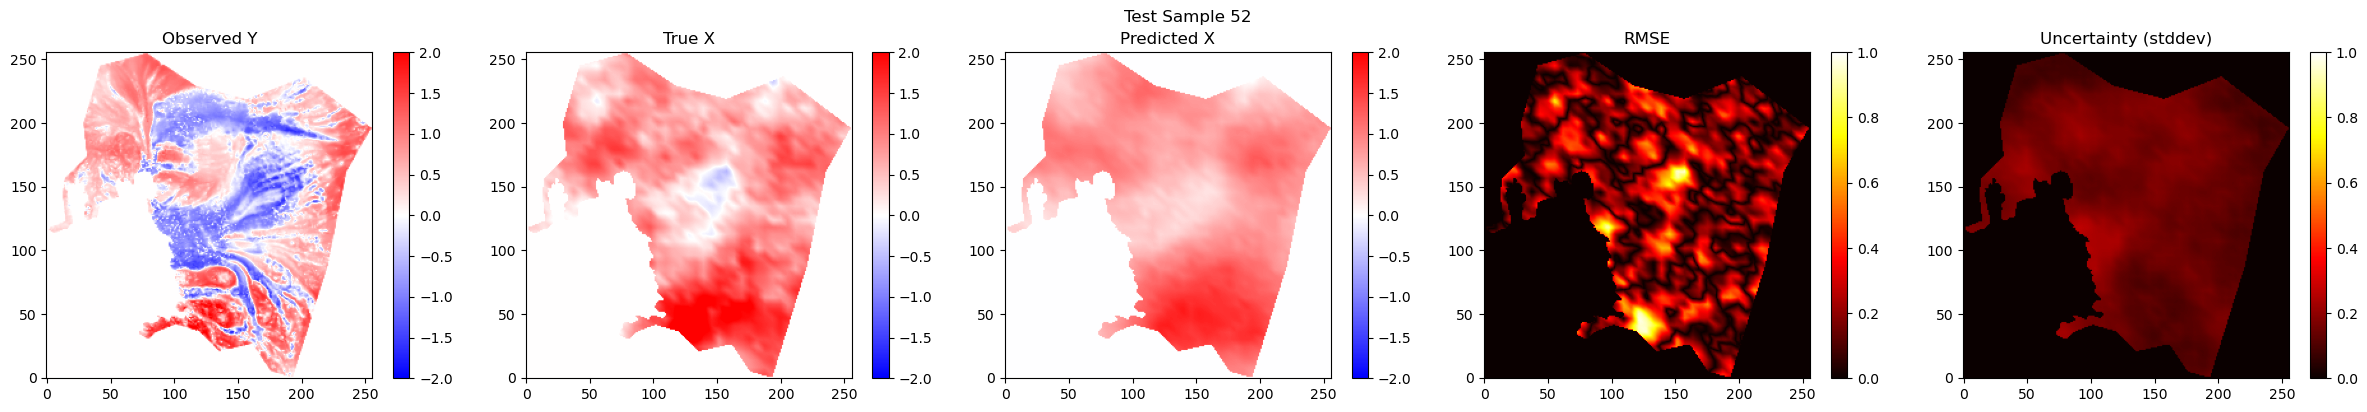

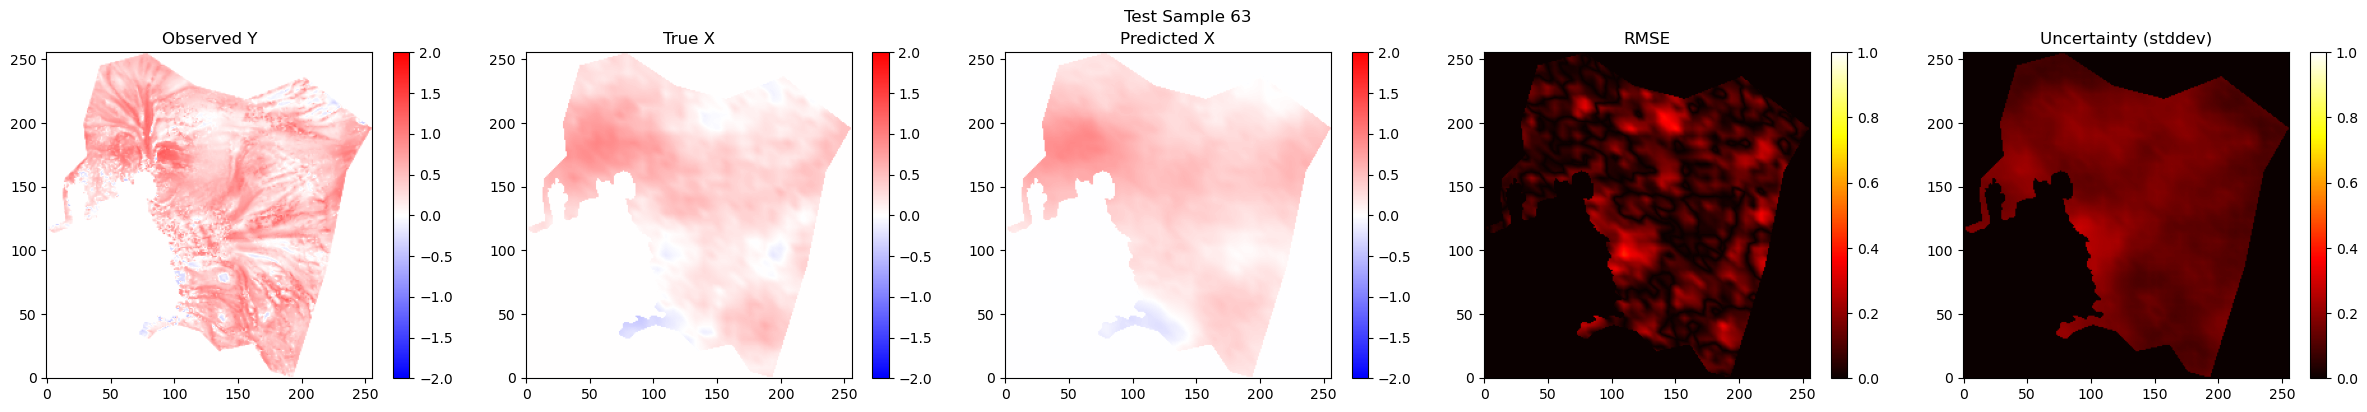

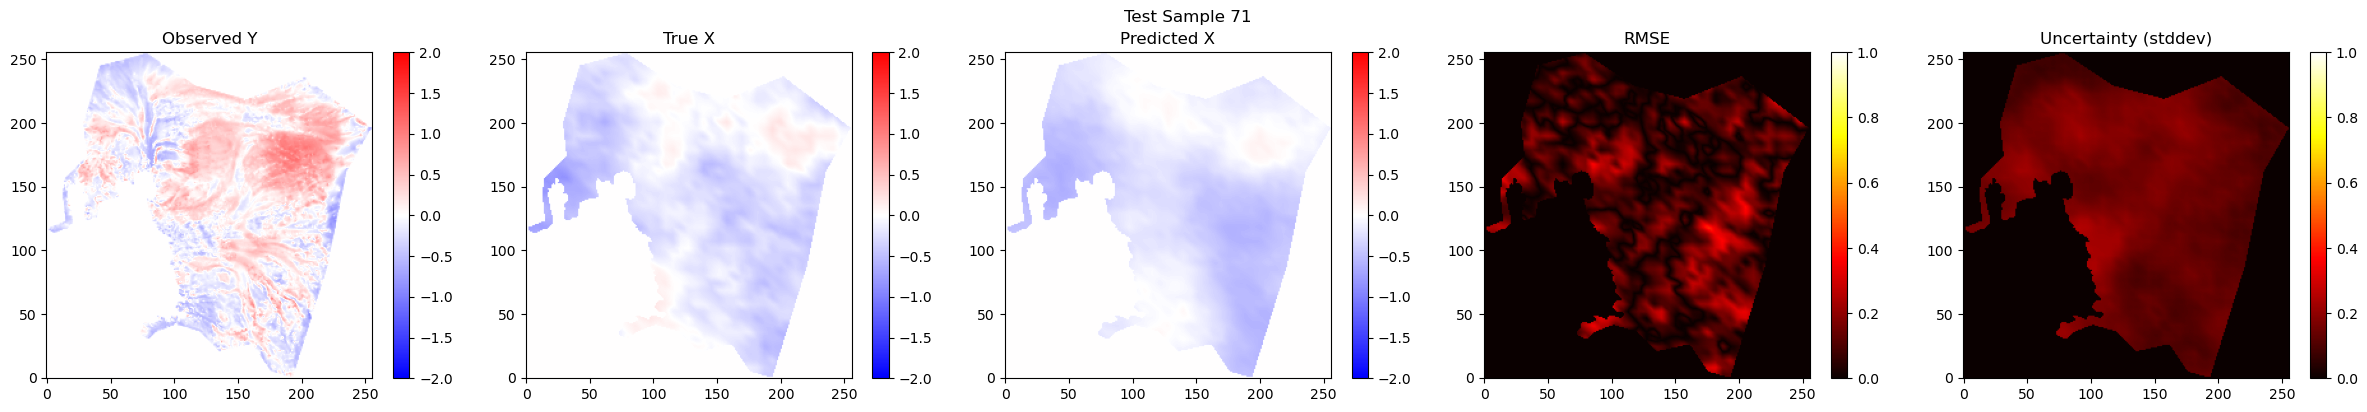

In [4]:
n_optimal = 3
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pls(n_samples=3)

# Infer on posterior basal enthalpy

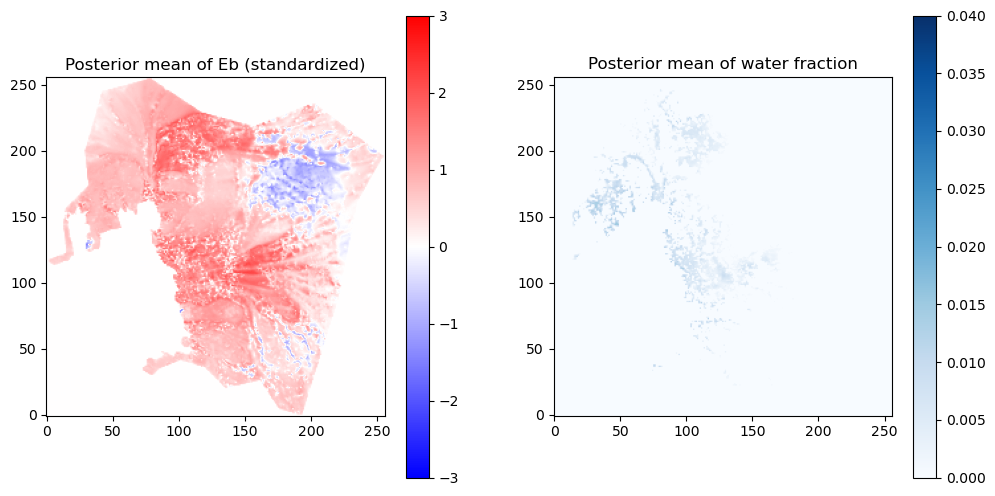

In [5]:
import torch
from src.ice import enthalpy_to_water_fraction
from src.utilities import reverse_standardize

Eb_posterior_sample_path = "../data/posterior-hmc-samples/Eb_samples_norm_beta_3.npy"
Eb_posterior_samples = np.load(Eb_posterior_sample_path)
mean_Eb_posterior = np.mean(Eb_posterior_samples, axis=0)
mean_Eb_posterior_ori = reverse_standardize(mean_Eb_posterior, md.Y_mean, md.Y_std,
                                            method="relaxation",epsilon=Eb_standardize_epsilon)
water_frac = enthalpy_to_water_fraction(mean_Eb_posterior_ori, 271.0, istorch=False)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(np.mean(Eb_posterior_samples, axis=0).reshape(md.nx, md.ny), cmap='bwr', vmin=-3, vmax=3)
plt.gca().invert_yaxis()
plt.colorbar()
plt.title("Posterior mean of Eb (standardized)")
plt.subplot(1,2,2)
plt.imshow(water_frac.reshape(md.nx, md.ny), cmap='Blues', vmin=0, vmax=0.04)
plt.gca().invert_yaxis()
plt.colorbar()
plt.title("Posterior mean of water fraction")
plt.show()

In [6]:
# use each sample as a condition on md.gmm
n_uq_sample = 100
GHF_conditioned_samples = []
for i, sample in enumerate(Eb_posterior_samples):

    y_latent = md.pca_x.transform(sample.reshape(1, -1)) @ md.pls.x_loadings_ 
    condition_index = np.arange(md.ndim_reduced_y)
    x_pred_gmm = md.gmm.condition(condition_index, y_latent)

    x_uq_samples = x_pred_gmm.sample(n_uq_sample)   # shape (400, 12)
    GHF_conditioned_samples.append(x_uq_samples)

    if i%500==0:
        print(f"Processed {i}/{len(Eb_posterior_samples)} samples")


Processed 0/3000 samples
Processed 500/3000 samples
Processed 1000/3000 samples
Processed 1500/3000 samples
Processed 2000/3000 samples
Processed 2500/3000 samples


In [7]:
from src.utilities import reverse_standardize

GHF_conditioned_samples = np.vstack(GHF_conditioned_samples) # shape (n_samples, n_uq_sample, n_features)   
print("Shape of GHF_conditioned_samples:", GHF_conditioned_samples.shape)


N = GHF_conditioned_samples.shape[0]
n_pixels = md.nx * md.ny  # 65536
chunk_size = 1000  # process 1000 samples at a time → ~500MB peak

# Welford's online algorithm for mean + variance (no storage of all samples)
# For percentiles we need a different approach — reservoir or chunked sort
# Strategy: store only what's needed per pixel

# --- Mean and Std via Welford (O(n_pixels) memory) ---
running_mean = np.zeros(n_pixels)
running_M2   = np.zeros(n_pixels)  # sum of squared deviations

for start in range(0, N, chunk_size):
    end = min(start + chunk_size, N)
    chunk = GHF_conditioned_samples[start:end]          # (chunk, 40)
    
    chunk_pca   = chunk @ md.pls.x_loadings_.T          # (chunk, 50)
    chunk_pixel = md.pca_x.inverse_transform(chunk_pca) # (chunk, n_pixels)
    
    # reverse standardization
    chunk_pixel = reverse_standardize(chunk_pixel, 
                                      md.X_mean, 
                                      md.X_std, 
                                      method='relaxation', 
                                      epsilon=GHF_standardize_epsilon)
    
    # Welford update
    for i in range(len(chunk_pixel)):
        n_seen = start + i + 1
        delta  = chunk_pixel[i] - running_mean
        running_mean += delta / n_seen
        delta2 = chunk_pixel[i] - running_mean
        running_M2   += delta * delta2

    if start % (10*chunk_size) == 0:
        print(f"Processed {start} / {N} samples for mean/std")

GHF_mean = running_mean.reshape(md.nx, md.ny)
GHF_std  = np.sqrt(running_M2 / N).reshape(md.nx, md.ny)

# --- Percentiles via reservoir: store sorted values per pixel ---
# This is the hard part. Two practical options:

# OPTION A: Subsample (fast, approximate)
# If N=120000, taking 5000 random samples gives very accurate percentiles
rng = np.random.default_rng(42)
idx_sub = rng.choice(N, size=5000, replace=False)
sub_pca   = GHF_conditioned_samples[idx_sub] @ md.pls.x_loadings_.T
sub_pixel = md.pca_x.inverse_transform(sub_pca)
sub_pixel = reverse_standardize(sub_pixel, 
                                md.X_mean, 
                                md.X_std, 
                                method='relaxation', 
                                epsilon=GHF_standardize_epsilon)
# shape: (5000, n_pixels) → ~2.6 GB, borderline — reduce to 2000 if needed

GHF_p01 = np.percentile(sub_pixel,  1, axis=0).reshape(md.nx, md.ny)
GHF_p05 = np.percentile(sub_pixel,  5, axis=0).reshape(md.nx, md.ny)
GHF_p95 = np.percentile(sub_pixel, 95, axis=0).reshape(md.nx, md.ny)
GHF_p99 = np.percentile(sub_pixel, 99, axis=0).reshape(md.nx, md.ny)
del sub_pixel  # free immediately


Shape of GHF_conditioned_samples: (300000, 40)
Processed 0 / 300000 samples for mean/std
Processed 10000 / 300000 samples for mean/std
Processed 20000 / 300000 samples for mean/std
Processed 30000 / 300000 samples for mean/std
Processed 40000 / 300000 samples for mean/std
Processed 50000 / 300000 samples for mean/std
Processed 60000 / 300000 samples for mean/std
Processed 70000 / 300000 samples for mean/std
Processed 80000 / 300000 samples for mean/std
Processed 90000 / 300000 samples for mean/std
Processed 100000 / 300000 samples for mean/std
Processed 110000 / 300000 samples for mean/std
Processed 120000 / 300000 samples for mean/std
Processed 130000 / 300000 samples for mean/std
Processed 140000 / 300000 samples for mean/std
Processed 150000 / 300000 samples for mean/std
Processed 160000 / 300000 samples for mean/std
Processed 170000 / 300000 samples for mean/std
Processed 180000 / 300000 samples for mean/std
Processed 190000 / 300000 samples for mean/std
Processed 200000 / 300000 s

## Load ice velocity and volcano locations

In [8]:
import netCDF4 as nc
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from pyproj import Proj, transform


vel_path = '../../common-data-set/velocity/antarctica_ice_velocity_450m_v2.nc'

# ── Step 1: Read only the index ranges we need, not the full array ────────
ds  = nc.Dataset(vel_path)
x   = np.array(ds['x'][:], dtype=np.float32)
y   = np.array(ds['y'][:], dtype=np.float32)

padding = 50e3
xmin, xmax = md.coord[0].min() - padding, md.coord[0].max() + padding
ymin, ymax = md.coord[1].min() - padding, md.coord[1].max() + padding

x_idx = np.where((x >= xmin) & (x <= xmax))[0]
y_idx = np.where((y >= ymin) & (y <= ymax))[0]

# Slice indices — load only the cropped region directly from disk
xi_s, xi_e = x_idx[0], x_idx[-1] + 1
yi_s, yi_e = y_idx[0], y_idx[-1] + 1

print(f"Loading cropped region: {yi_e - yi_s} × {xi_e - xi_s} pixels")

vx = np.array(ds['VX'][yi_s:yi_e, xi_s:xi_e], dtype=np.float32)
vy = np.array(ds['VY'][yi_s:yi_e, xi_s:xi_e], dtype=np.float32)
ds.close()

x_c = x[xi_s:xi_e]
y_c = y[yi_s:yi_e]

# ── Step 2: Compute speed in-place to avoid holding vx, vy, vel together ─
vel_c = np.hypot(vx, vy)   # in-place equivalent, no extra copy
del vx, vy                 # free immediately

print(f"vel_c shape: {vel_c.shape}, memory: {vel_c.nbytes / 1e6:.1f} MB")

# ── Step 3: RegularGridInterpolator instead of griddata ───────────────────
# griddata does an unstructured Delaunay triangulation → O(N log N) memory
# RegularGridInterpolator exploits the regular grid → O(1) memory overhead
interp_fn = RegularGridInterpolator(
    (y_c, x_c),          # axes must match array shape (row=y, col=x)
    vel_c,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)
del vel_c                  # free the source array before allocating output

X, Y = np.meshgrid(md.coord[0], md.coord[1])  # shape (ny, nx)
query_points = np.column_stack((
    Y.flatten(),   # y first
    X.flatten()    # x second
))

vel_interp = interp_fn(query_points).reshape(md.nx, md.ny)
print(f"Interpolation complete. Output shape: {vel_interp.shape}")


Loading cropped region: 2280 × 2112 pixels
vel_c shape: (2280, 2112), memory: 19.3 MB
Interpolation complete. Output shape: (256, 256)


In [9]:
from pyproj import Transformer
from scipy.interpolate import griddata

# ── Load and filter by confidence ────────────────────────────────────────
volcano_path = "../data/other-inputs/vanWykDeVries2017_Table2_subglacial_cones.csv"
volcano      = pd.read_csv(volcano_path)

confidence_threshold = 4
conf_mask    = volcano['Confidence_Sum'].values >= confidence_threshold
volcano_lat  = volcano['Latitude'].values[conf_mask]
volcano_lon  = volcano['Longitude'].values[conf_mask]
volcano_conf = volcano['Confidence_Sum'].values[conf_mask]

# ── Project lat/lon → polar stereographic (same as model grid) ───────────
transformer  = Transformer.from_crs("epsg:4326", "epsg:3031", always_xy=True)
volcano_x, volcano_y = transformer.transform(volcano_lon, volcano_lat)

# ── Find which volcanoes fall inside the model domain ────────────────────
X_md, Y_md  = np.meshgrid(md.coord[0], md.coord[1])
grid_points = np.column_stack((X_md.flatten(), Y_md.flatten()))

domain_at_volcanoes = griddata(
    grid_points,
    model_bound_data_ori.flatten(),
    np.column_stack((volcano_x, volcano_y)),
    method='nearest'
)
volcano_in_domain    = domain_at_volcanoes.astype(bool)
volcano_x_in_domain  = volcano_x[volcano_in_domain]
volcano_y_in_domain  = volcano_y[volcano_in_domain]
volcano_conf_in_domain = volcano_conf[volcano_in_domain]

print(f"Volcanoes after confidence filter: {len(volcano_lat)}")
print(f"Volcanoes inside model domain:     {len(volcano_x_in_domain)}")


Volcanoes after confidence filter: 62
Volcanoes inside model domain:     21


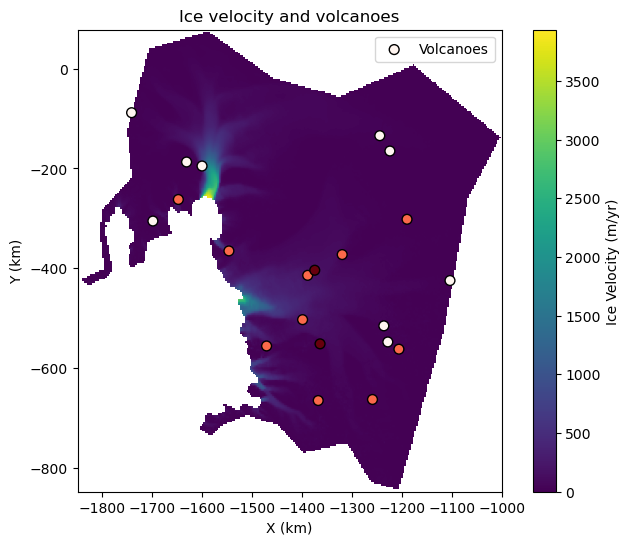

In [10]:
vel_interp[model_bound_data_ori == False] = np.nan
# Unpack extent for reference
xmin, xmax, ymax_orig, ymin_orig = md.extent  # note: your extent is [x0, x1, ytop, ybottom]

corrected_extent = [xmin, xmax, ymin_orig, ymax_orig]  # now [xmin, xmax, -848, 78.1]
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    vel_interp,
    extent=corrected_extent,
    origin='lower',
    cmap='viridis'
)

plt.colorbar(im, ax=ax, label='Ice Velocity (m/yr)')

# Scatter: coordinates must match the extent's coordinate system
ax.scatter(
    volcano_x_in_domain / 1e3,
    volcano_y_in_domain / 1e3,
    c=volcano_conf_in_domain,
    cmap='Reds',
    edgecolor='k',
    s=50,
    label='Volcanoes'
)

ax.set_title('Ice velocity and volcanoes')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.legend()
plt.show()


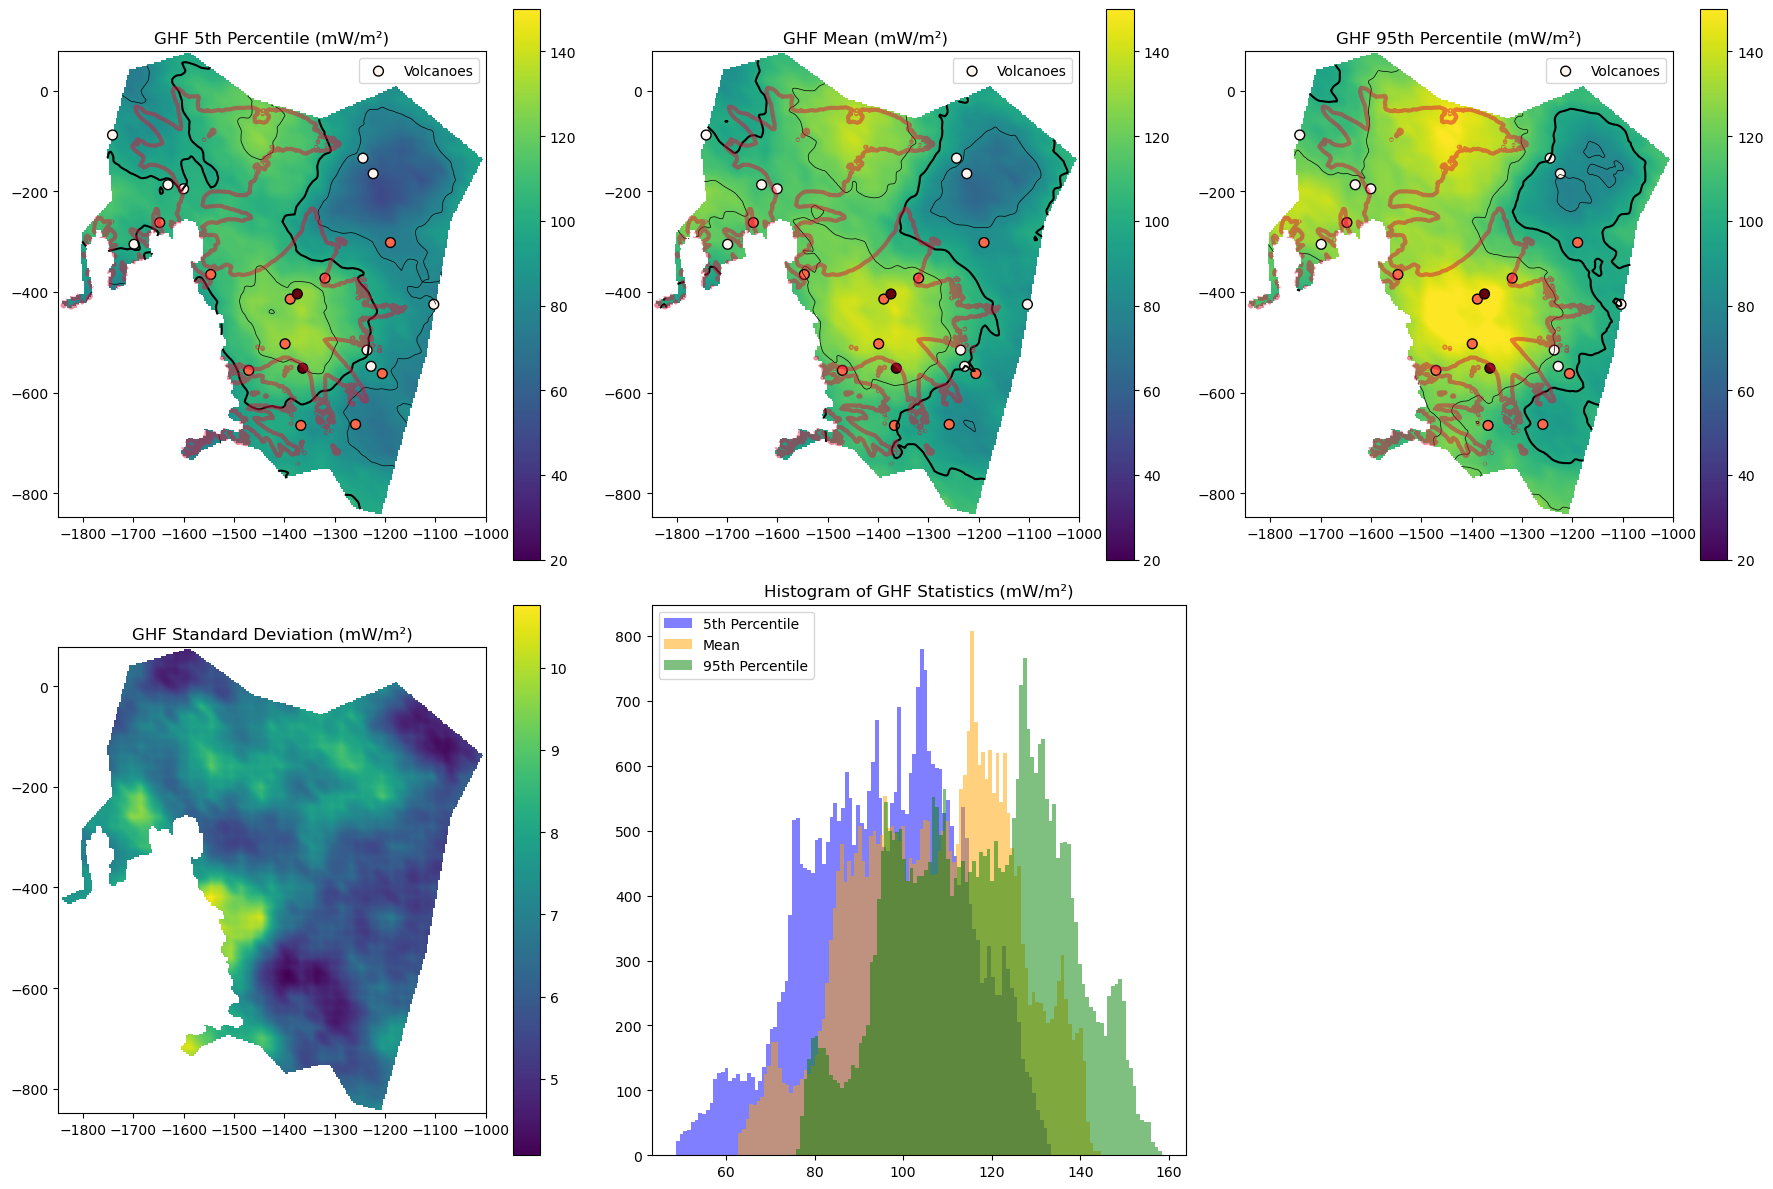

In [11]:
contour_levels      = [40, 80, 120, 160, 200]
contour_bold_levels = [100, 200]
vel_contour_levels = [50]

GHF_p05[~model_bound_data_ori]  = np.nan
GHF_mean[~model_bound_data_ori] = np.nan
GHF_p95[~model_bound_data_ori]  = np.nan
GHF_std[~model_bound_data_ori]  = np.nan

xmin, xmax, ymax_orig, ymin_orig = md.extent  # note: your extent is [x0, x1, ytop, ybottom]
corrected_extent = [xmin, xmax, ymin_orig, ymax_orig]  # now [xmin, xmax, -848, 78.1]

def plot_ghf_panel(ax, data_mW, title, extent, vmin=20, vmax=200):
    im = ax.imshow(
        data_mW,
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        extent=extent,
        origin='lower'       # ← explicit
    )
    plt.colorbar(im, ax=ax)
    ax.contour(
        data_mW,
        levels=contour_levels,
        colors='black', linewidths=0.5,
        extent=extent,
        origin='lower'       # ← must match imshow
    )
    ax.contour(
        data_mW,
        levels=contour_bold_levels,
        colors='black', linewidths=1.5,
        extent=extent,
        origin='lower'       # ← must match imshow
    )
    ax.contour( 
        vel_interp.reshape(md.nx, md.ny),
        levels=vel_contour_levels,
        colors='crimson', linewidths=3,
        alpha=0.5,
        # dash line
        extent=extent,
        origin='lower'       # ← must match imshow
    )
    ax.scatter(
        volcano_x_in_domain / 1e3,
        volcano_y_in_domain / 1e3,
        c=volcano_conf_in_domain,
        cmap='Reds',
        edgecolor='k',
        s=50,
        label='Volcanoes'
    )
    ax.legend()
    ax.set_title(title)
    # do NOT call invert_yaxis() — extent already sets the axis direction

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_ghf_panel(axes[0,0], GHF_p05  * 1e3, 'GHF 5th Percentile (mW/m²)',  corrected_extent, vmax=150)
plot_ghf_panel(axes[0,1], GHF_mean * 1e3, 'GHF Mean (mW/m²)',             corrected_extent, vmax=150)
plot_ghf_panel(axes[0,2], GHF_p95  * 1e3, 'GHF 95th Percentile (mW/m²)', corrected_extent, vmax=150)

# std — no vmin/vmax clipping
im_std = axes[1,0].imshow(GHF_std * 1e3, cmap='viridis', extent=corrected_extent, origin='lower')
plt.colorbar(im_std, ax=axes[1,0])
axes[1,0].set_title('GHF Standard Deviation (mW/m²)')

# histogram
axes[1,1].hist(GHF_p05[model_bound_data_ori].flatten()  * 1e3, bins=100, color='blue',   alpha=0.5)
axes[1,1].hist(GHF_mean[model_bound_data_ori].flatten() * 1e3, bins=100, color='orange', alpha=0.5)
axes[1,1].hist(GHF_p95[model_bound_data_ori].flatten()  * 1e3, bins=100, color='green',  alpha=0.5)
axes[1,1].legend(['5th Percentile', 'Mean', '95th Percentile'])
axes[1,1].set_title('Histogram of GHF Statistics (mW/m²)')

axes[1,2].set_visible(False)  # empty 6th panel

plt.tight_layout()
plt.savefig("../figs/GHF_inference_results.png", dpi=300)
plt.show()


# Compare to existing GHF maps

In [12]:
# my import util functions
thermal_folder = "/home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/"
sys.path.append(os.path.abspath(thermal_folder + "functions/"))
from importGHFutils import importHazzard, importHaeger, importMartos, importLoesing, importShen, importStaal

# import more tools
from readExpFile import readExpFile
from importGHFutils import filterDatasetsByDrainage, plotGHFMaps

# drainage basin domain outline
ase_drainage_dir = thermal_folder + "exp-files/drainage_G-H.exp"

# GHF maps for Antarctica
raw_folder = thermal_folder + "external-data/GHF/raw/"

# file names
haeger_filename = "Haeger2022/2022-002_Haeger-et-al_HFSurface.txt"
hazzard_filename = "Hazzard-Richards2024/HR24_grids/model_output/HR24_GHF_mean.grd" # what is this format
loesing_filename = "Loesing-Ebbing2021/HF_Min_Max_MaxAbs-1.csv" # ...-1 comes from the "updated" version with addition data
lucazeau_filename = "Lucazeau2019/HFgrid14.csv"
martos_filename = "Martos2017/Martos2017.xyz"
shen_filename = "Shen2020/shen2020-GHF.hf.v1.xyz"
staal_filename = "Staal2020/aq1_01_20.nc"


No NaN values found in 549081 entries.


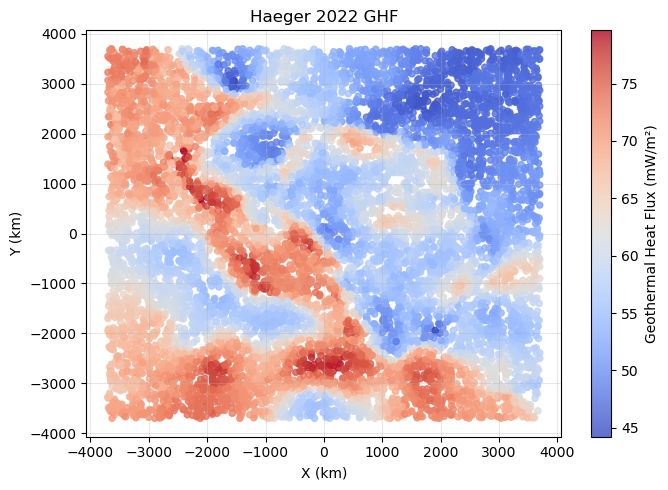

In [13]:
haeger = importHaeger(raw_folder + haeger_filename)

Flattened shapes: (43981,) (43981,) (43981,)
NaN values in GHF: 16972 out of 43981 (38.59%)
Remaining entries after NaN removal: 27009


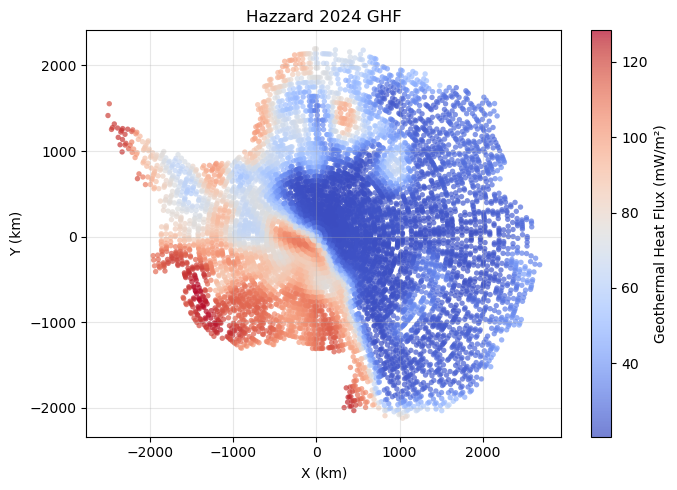

In [14]:
hazzard = importHazzard(raw_folder + hazzard_filename)

Using 'HF [mW/m2]' as the heat flux column


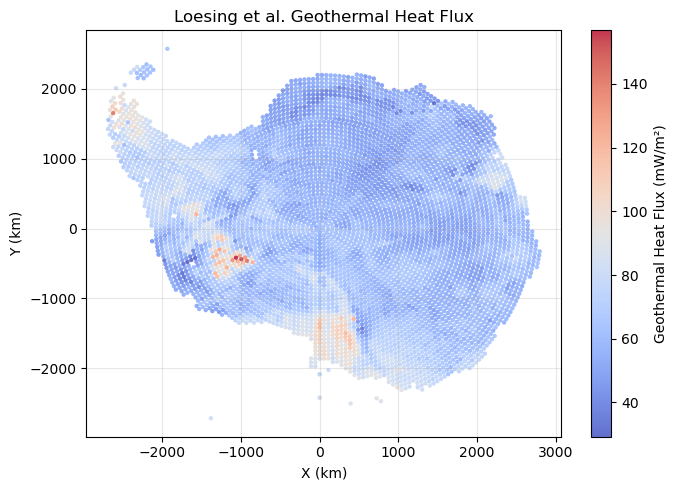

In [15]:
loesing = importLoesing(raw_folder + loesing_filename)

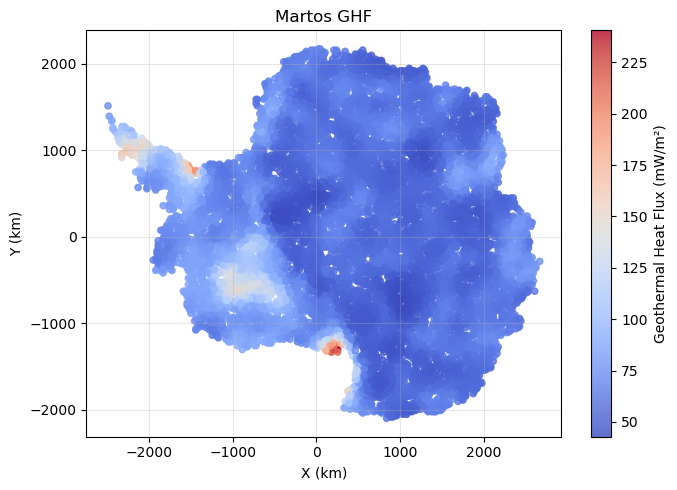

In [16]:
martos = importMartos(raw_folder + martos_filename, 10000)

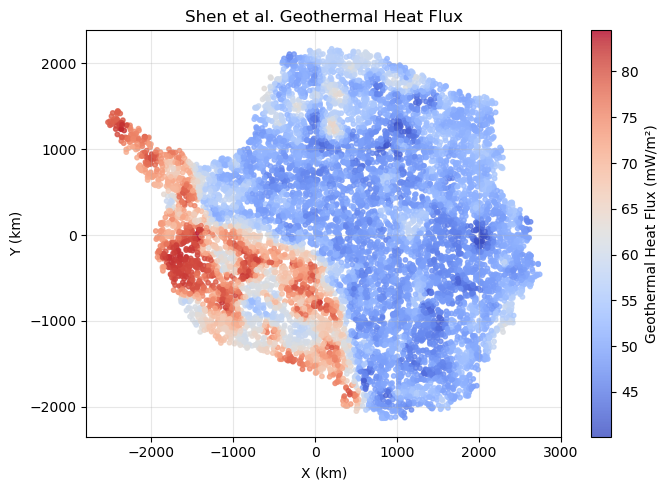

In [17]:
shen = importShen(raw_folder+shen_filename)

X shape: (280,)
Y shape: (280,)
Q shape: (280, 280)
Q is already a 2D grid
Staal dataset has 31897 points, subsampling to 10000 points
Imported Staal dataset with 10000 points


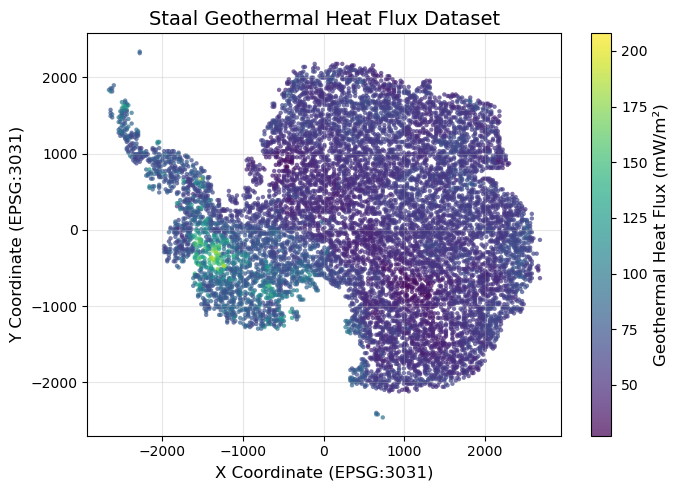

In [18]:
staal = importStaal(raw_folder+staal_filename)

In [19]:
ase_drainage = readExpFile(ase_drainage_dir)/1e3 # convert to km
datasets = {'haeger':haeger,
            'hazzard':hazzard,
            'loesing':loesing,
            'martos':martos,
            'shen':shen,
            'staal':staal}


# Filter all datasets by the ASE drainage boundary
filtered_datasets = filterDatasetsByDrainage(datasets, ase_drainage)

del datasets, haeger, hazzard, loesing, martos, shen, staal

Successfully read 1766 data points from /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/exp-files/drainage_G-H.exp
Skipped 1 lines due to empty lines, format issues, or NaN values
Filtering datasets by ASE drainage boundary:
--------------------------------------------------

Processing haeger:
Original data points: 549081
Points within ASE drainage boundary: 4200
Filtered out 544881 points (99.2%)

Processing hazzard:
Original data points: 27009
Points within ASE drainage boundary: 618
Filtered out 26391 points (97.7%)

Processing loesing:
Original data points: 5463
Points within ASE drainage boundary: 138
Filtered out 5325 points (97.5%)

Processing martos:
Original data points: 59328
Points within ASE drainage boundary: 1854
Filtered out 57474 points (96.9%)

Processing shen:
Original data points: 469806
Points within ASE drainage boundary: 14300
Filtered out 455506 points (97.0%)

Processing staal:
Original data points: 10000
Points within ASE drainage boundary: 336

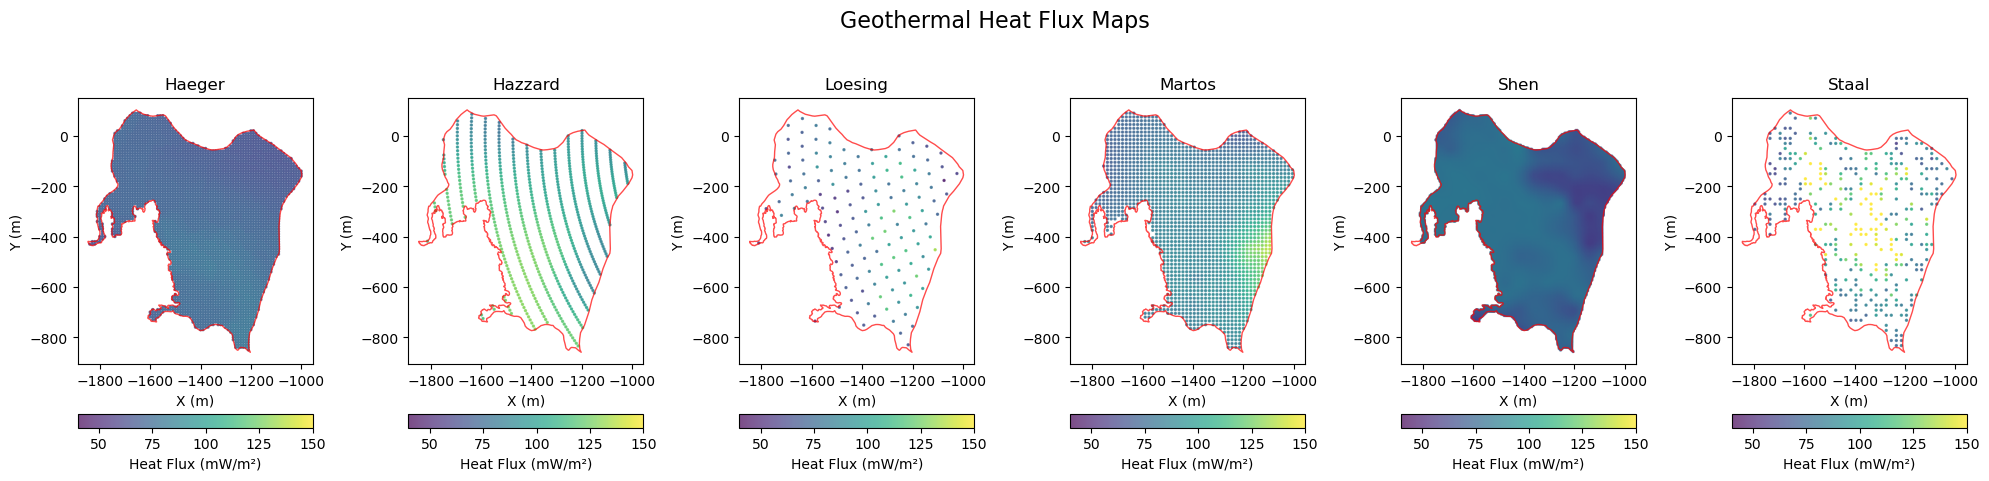

In [20]:
fig = plotGHFMaps(filtered_datasets, ase_drainage, vmin=40, vmax = 150)

In [21]:
from matplotlib.path import Path
from scipy.interpolate import griddata
import numpy as np
import pandas as pd

# ── query_points is [Y, X] in metres ─────────────────────────────────────────
qp_y = query_points[:, 0]   # metres
qp_x = query_points[:, 1]   # metres
grid_points_xy = np.column_stack([qp_x, qp_y])   # [X, Y] for griddata & Path

# ── Polygon in metres ─────────────────────────────────────────────────────────
coords_x = ase_drainage['x_3031'].values.astype(float) * 1000
coords_y = ase_drainage['y_3031'].values.astype(float) * 1000

coords = np.column_stack([coords_x, coords_y])   # [X, Y]
if not np.allclose(coords[0], coords[-1]):
    coords = np.vstack([coords, coords[0]])

poly_path   = Path(coords)
inside_mask = poly_path.contains_points(grid_points_xy, radius=100)

print(f"Total grid cells    : {len(grid_points_xy):,}")
print(f"Cells inside polygon: {inside_mask.sum():,}")

# ── Extract xyz in metres ─────────────────────────────────────────────────────
def extract_xyz(df):
    x = df['x_3031'].values.astype(float) * 1000
    y = df['y_3031'].values.astype(float) * 1000
    ghf_col = next(
        c for c in df.columns
        if 'ghf' in c.lower() and 'std' not in c.lower()
    )
    z = df[ghf_col].values.astype(float)
    ok = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
    return x[ok], y[ok], z[ok]

# ── Interpolate ───────────────────────────────────────────────────────────────
ghf_grids = {}

for name, df in filtered_datasets.items():
    x, y, z = extract_xyz(df)

    z_interp = griddata(
        np.column_stack([x, y]), z,
        grid_points_xy, method='linear'
    )

    nan_idx = np.isnan(z_interp)
    if nan_idx.any():
        z_interp[nan_idx] = griddata(
            np.column_stack([x, y]), z,
            grid_points_xy[nan_idx], method='nearest'
        )

    z_interp[~inside_mask] = np.nan
    ghf_grids[name] = z_interp
    print(f"  {name:12s} → valid cells: {np.sum(~np.isnan(z_interp)):>6,}")

# ── Ensemble stats ────────────────────────────────────────────────────────────
stack     = np.vstack(list(ghf_grids.values()))
ghf_mean  = np.nanmean(stack, axis=0)
ghf_std   = np.nanstd(stack,  axis=0)
ghf_count = np.sum(~np.isnan(stack), axis=0)

print(f"\nEnsemble mean GHF : {np.nanmean(ghf_mean):.3f} mW/m²")
print(f"Ensemble std  GHF : {np.nanmean(ghf_std):.3f}  mW/m²")

# ── Output DataFrame ──────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'x_3031_m'  : qp_x,
    'y_3031_m'  : qp_y,
    **{f'ghf_{name}': ghf_grids[name] for name in ghf_grids},
    'ghf_mean'  : ghf_mean,
    'ghf_std'   : ghf_std,
    'n_datasets': ghf_count,
})

results_df = results_df[inside_mask].reset_index(drop=True)
print(f"\nFinal grid shape: {results_df.shape}")
print(results_df.head())


Total grid cells    : 65,536
Cells inside polygon: 34,584
  haeger       → valid cells: 34,584
  hazzard      → valid cells: 34,584
  loesing      → valid cells: 34,584
  martos       → valid cells: 34,584
  shen         → valid cells: 34,584
  staal        → valid cells: 34,584

Ensemble mean GHF : 87.338 mW/m²
Ensemble std  GHF : 17.506  mW/m²

Final grid shape: (34584, 11)
       x_3031_m  y_3031_m  ghf_haeger  ghf_hazzard  ghf_loesing  ghf_martos  \
0 -1.256667e+06 -848000.0   77.434600   121.920540       64.901   79.811432   
1 -1.253333e+06 -848000.0   78.366800   121.920540       64.901   79.811432   
2 -1.250000e+06 -848000.0   78.366800   121.920540       64.901   80.485306   
3 -1.216667e+06 -848000.0   78.917053   121.736603       64.901   81.699997   
4 -1.213333e+06 -848000.0   78.920200   121.736603       64.901   81.699997   

    ghf_shen  ghf_staal   ghf_mean    ghf_std  n_datasets  
0  74.281374  73.549824  81.983128  18.451012           6  
1  74.183110  73.549824  8

/tmp/ipykernel_1571692/2324153279.py:61: RuntimeWarning: Mean of empty slice
  ghf_mean  = np.nanmean(stack, axis=0)
/home/donglaiyang/anaconda3/envs/SciML/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


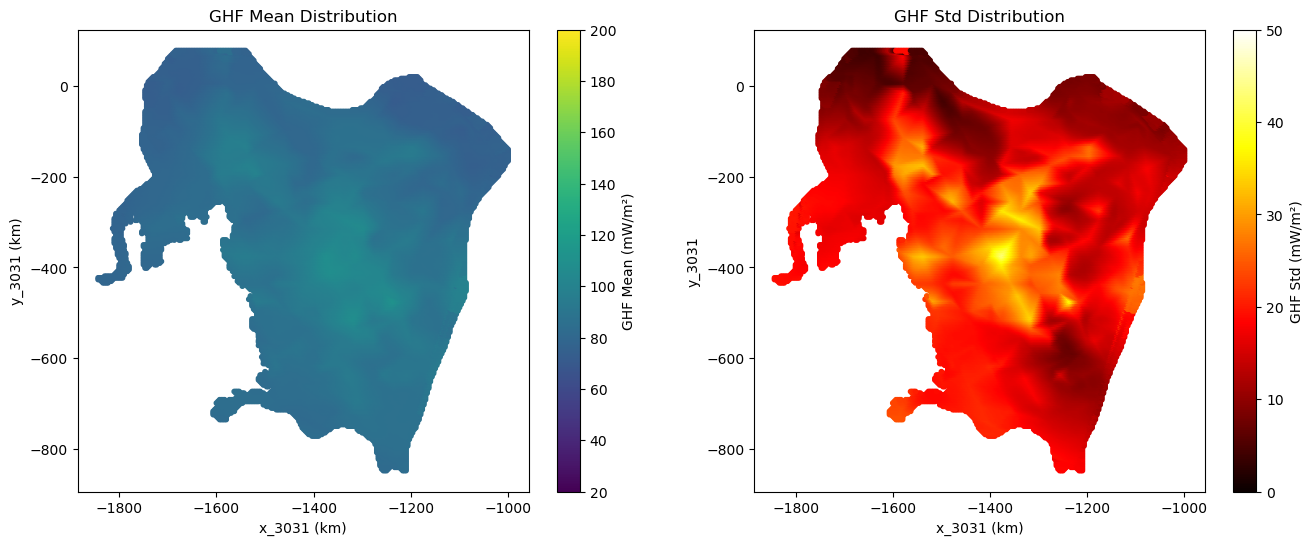

In [22]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(grid_points_xy[:, 0]/1e3, grid_points_xy[:, 1]/1e3, c=ghf_mean, cmap='viridis', 
            s=10, vmin=20, vmax=200)
plt.colorbar(label='GHF Mean (mW/m²)')
plt.xlabel('x_3031 (km)')
plt.ylabel('y_3031 (km)')
plt.title('GHF Mean Distribution')
plt.subplot(1, 2, 2)
plt.scatter(grid_points_xy[:, 0]/1e3, grid_points_xy[:, 1]/1e3, c=ghf_std, cmap='hot', s=10, vmin=0, vmax=50)
plt.colorbar(label='GHF Std (mW/m²)')
plt.xlabel('x_3031 (km)')
plt.ylabel('y_3031')
plt.title('GHF Std Distribution')
plt.show()  

In [23]:
regional_GHF = "/data-archive/download-extended/Dziadek-etal_2021_allfiles-20260522T182850Z-3-001/Dziadek-etal_2021_allfiles/"
filename = "200km_GHF_windowCenters.csv"
dziadek_ds = pd.read_csv(regional_GHF + filename)

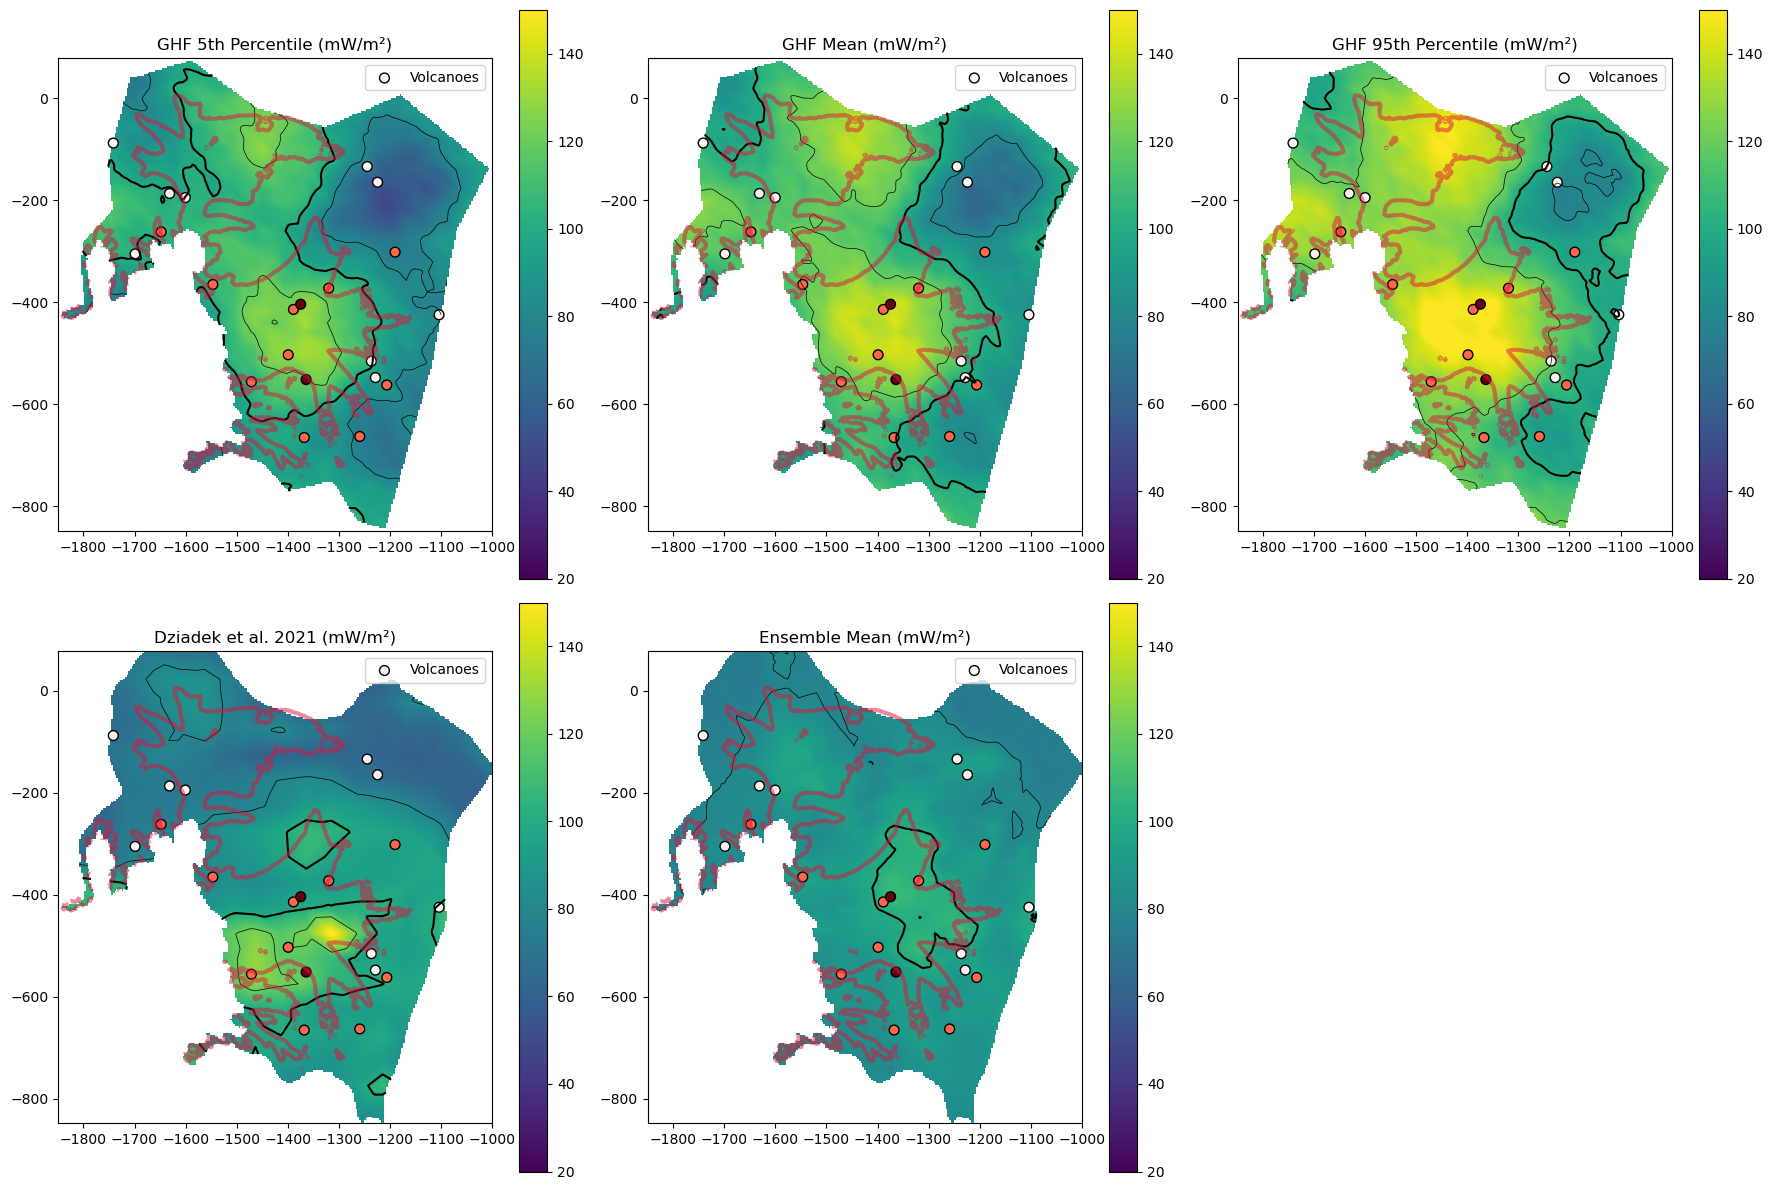

In [24]:
dziadek_x, dziadek_y = transformer.transform(dziadek_ds['Longitutde'].values, dziadek_ds['Latitude'].values)
dziadek_ghf = dziadek_ds['geothermal heat flow [mW/m²]'].values

# interpolate in the same way as the others
dziadek_interp = griddata(
    np.column_stack([dziadek_x/1e3, dziadek_y/1e3]), dziadek_ghf,
    grid_points_xy/1e3, method='linear'
)
dziadek_interp[~inside_mask] = np.nan

# plot all the GHF maps together
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_ghf_panel(axes[0,0], GHF_p05  * 1e3, 'GHF 5th Percentile (mW/m²)',  corrected_extent, vmax=150)
plot_ghf_panel(axes[0,1], GHF_mean * 1e3, 'GHF Mean (mW/m²)',             corrected_extent, vmax=150)
plot_ghf_panel(axes[0,2], GHF_p95  * 1e3, 'GHF 95th Percentile (mW/m²)', corrected_extent, vmax=150)
plot_ghf_panel(axes[1,0], dziadek_interp.reshape(md.nx, md.ny), 'Dziadek et al. 2021 (mW/m²)', corrected_extent, vmax=150)
plot_ghf_panel(axes[1,1], ghf_mean.reshape(md.nx, md.ny), 'Ensemble Mean (mW/m²)', corrected_extent, vmax=150)
plt.tight_layout()
axes[1,2].set_visible(False)  # empty 6th panel
plt.savefig("../figs/GHF_inference_comparerd.png", dpi=300)
plt.tight_layout()